In [2]:
import os, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

DIR_DATASET = 'dataset'
CLASSES = ['D', 'E', 'F', 'G']
NOMES = {'D': 'BI-RADS I', 'E': 'BI-RADS II', 'F': 'BI-RADS III', 'G': 'BI-RADS IV'}

def primeiro_arquivo(classe):
    return sorted(glob.glob(os.path.join(DIR_DATASET, classe, '*')))[0]

exemplos = {c: primeiro_arquivo(c) for c in CLASSES}
exemplos

{'D': 'dataset\\D\\d_right_mlo (1).png',
 'E': 'dataset\\E\\e_right_mlo (1).png',
 'F': 'dataset\\F\\f_right_mlo (1).png',
 'G': 'dataset\\G\\g_right_mlo (1).png'}

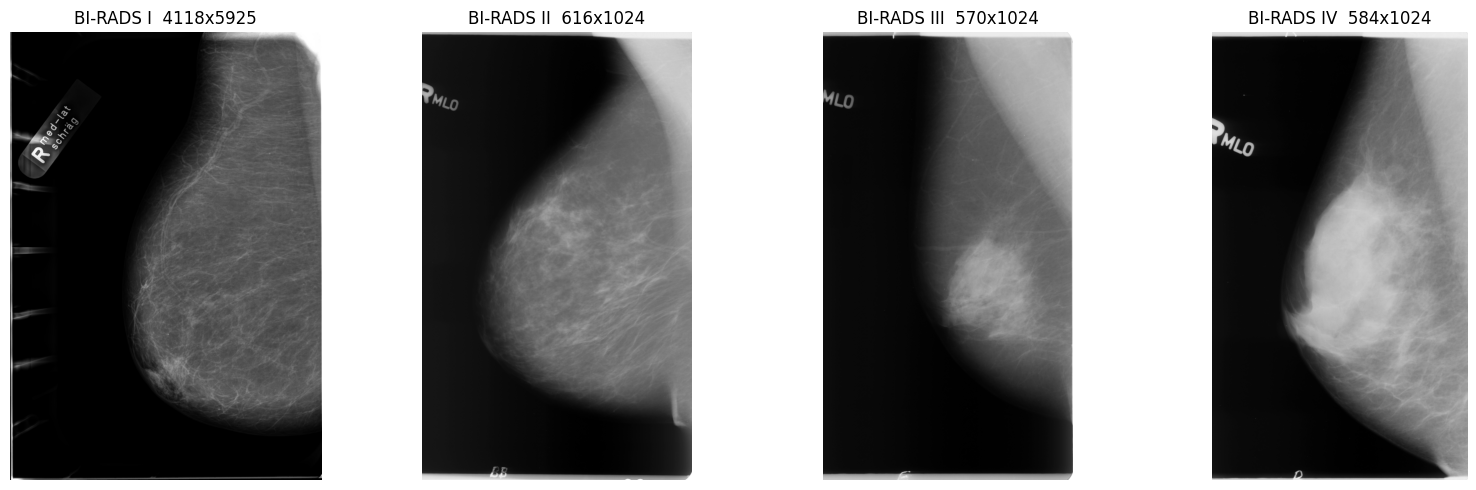

In [3]:
def carregar_cinza(caminho):
    bruta = cv2.imread(caminho, cv2.IMREAD_ANYDEPTH | cv2.IMREAD_GRAYSCALE)
    if bruta is None:
        bruta = cv2.imread(caminho, cv2.IMREAD_GRAYSCALE)
    if bruta.dtype != np.uint8:
        bruta = cv2.normalize(bruta, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return bruta

originais = {c: carregar_cinza(exemplos[c]) for c in CLASSES}
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
for ax, c in zip(axs, CLASSES):
    ax.imshow(originais[c], cmap='gray')
    ax.set_title(f"{NOMES[c]}  {originais[c].shape[1]}x{originais[c].shape[0]}")
    ax.axis('off')
plt.tight_layout(); plt.show()

In [4]:
def preparar(img_original, lado_maximo=1024):
    altura0, largura0 = img_original.shape
    img = img_original.copy()
    img[:int(altura0 * 0.12), :int(largura0 * 0.20)] = 0
    escala = min(1.0, lado_maximo / max(altura0, largura0))
    if escala < 1.0:
        img = cv2.resize(img, (int(largura0 * escala), int(altura0 * escala)), interpolation=cv2.INTER_AREA)
    h, w = img.shape
    m = max(5, int(min(h, w) * 0.02))
    img[:m, :] = 0; img[-m:, :] = 0; img[:, :m] = 0; img[:, -m:] = 0
    return img

reduzidas = {c: preparar(originais[c]) for c in CLASSES}
print({c: reduzidas[c].shape for c in CLASSES})

{'D': (1024, 711), 'E': (1024, 616), 'F': (1024, 570), 'G': (1024, 584)}


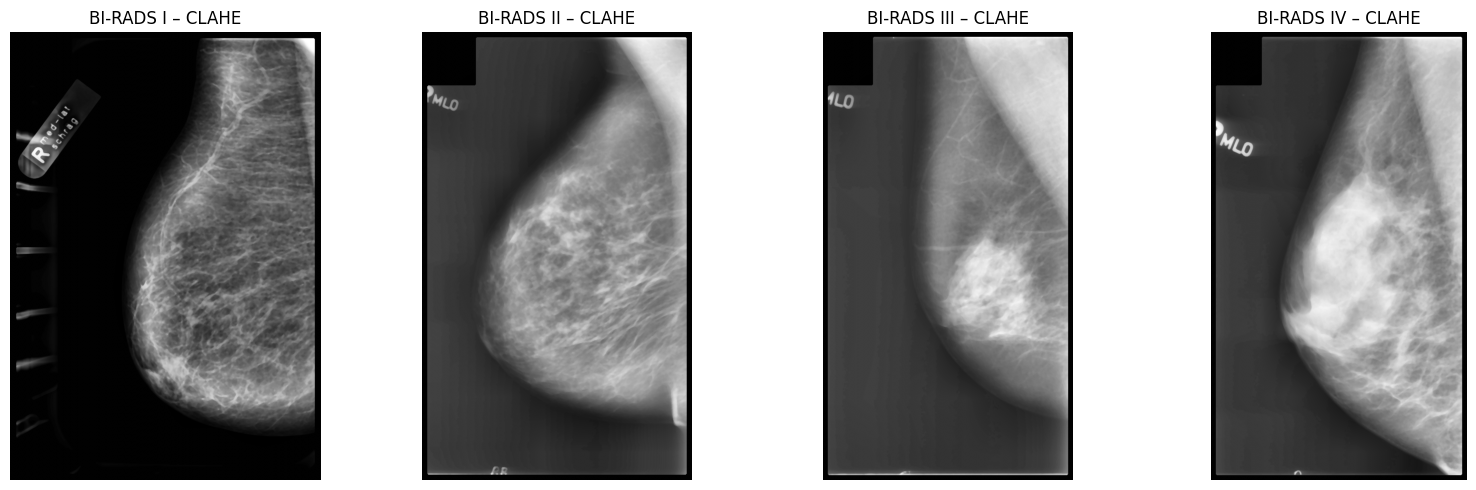

In [5]:
def realcar(img):
    suave = cv2.medianBlur(img, 5)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(suave)

realcadas = {c: realcar(reduzidas[c]) for c in CLASSES}
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
for ax, c in zip(axs, CLASSES):
    ax.imshow(realcadas[c], cmap='gray'); ax.set_title(f'{NOMES[c]} – CLAHE'); ax.axis('off')
plt.tight_layout(); plt.show()

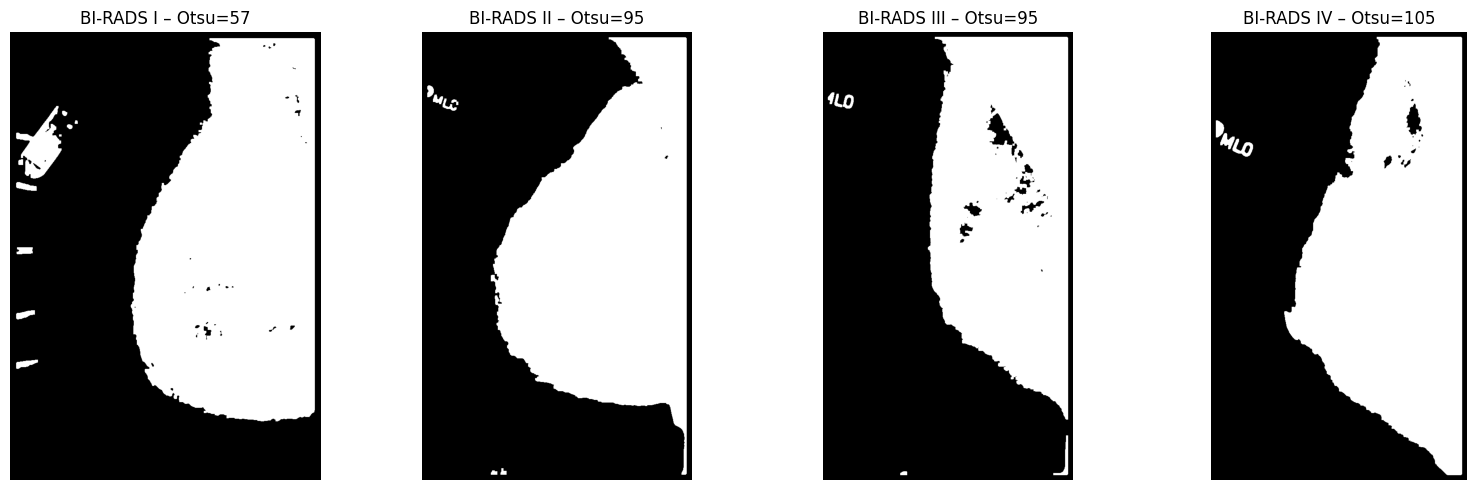

In [6]:
binarias = {}; limiares = {}
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
for ax, c in zip(axs, CLASSES):
    limiar, b = cv2.threshold(realcadas[c], 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    b = cv2.morphologyEx(b, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    binarias[c] = b; limiares[c] = limiar
    ax.imshow(b, cmap='gray'); ax.set_title(f'{NOMES[c]} – Otsu={limiar:.0f}'); ax.axis('off')
plt.tight_layout(); plt.show()

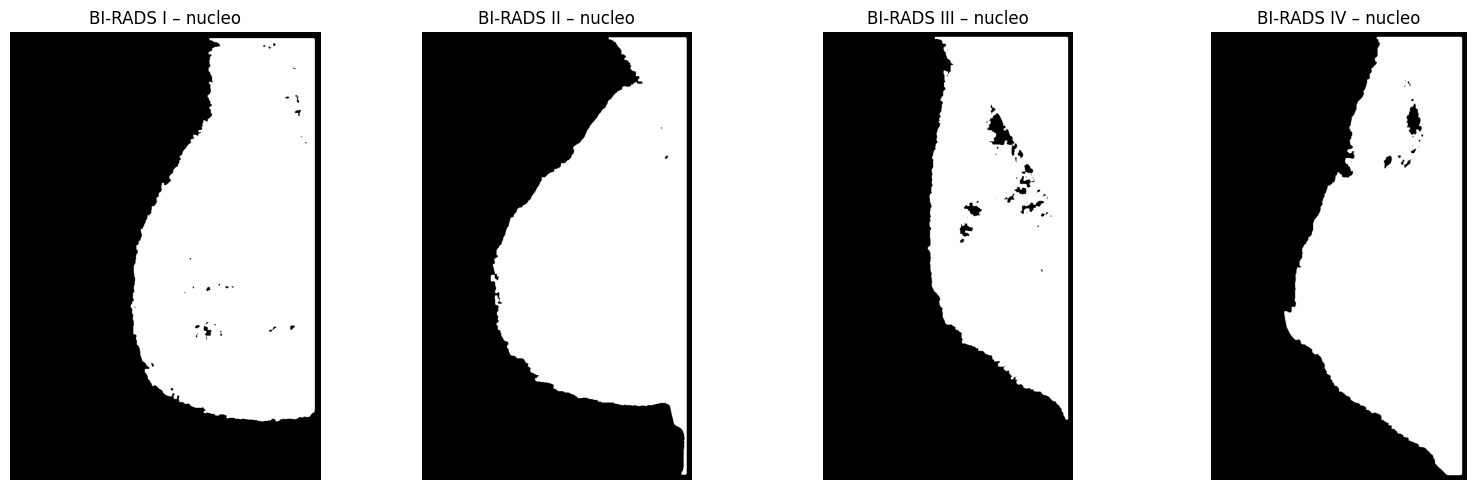

In [7]:
def maior_componente(mascara):
    n, rot, stats, _ = cv2.connectedComponentsWithStats(mascara)
    if n <= 1:
        return np.zeros_like(mascara)
    maior = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return np.where(rot == maior, 255, 0).astype(np.uint8)

nucleos = {c: maior_componente(binarias[c]) for c in CLASSES}
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
for ax, c in zip(axs, CLASSES):
    ax.imshow(nucleos[c], cmap='gray'); ax.set_title(f'{NOMES[c]} – nucleo'); ax.axis('off')
plt.tight_layout(); plt.show()

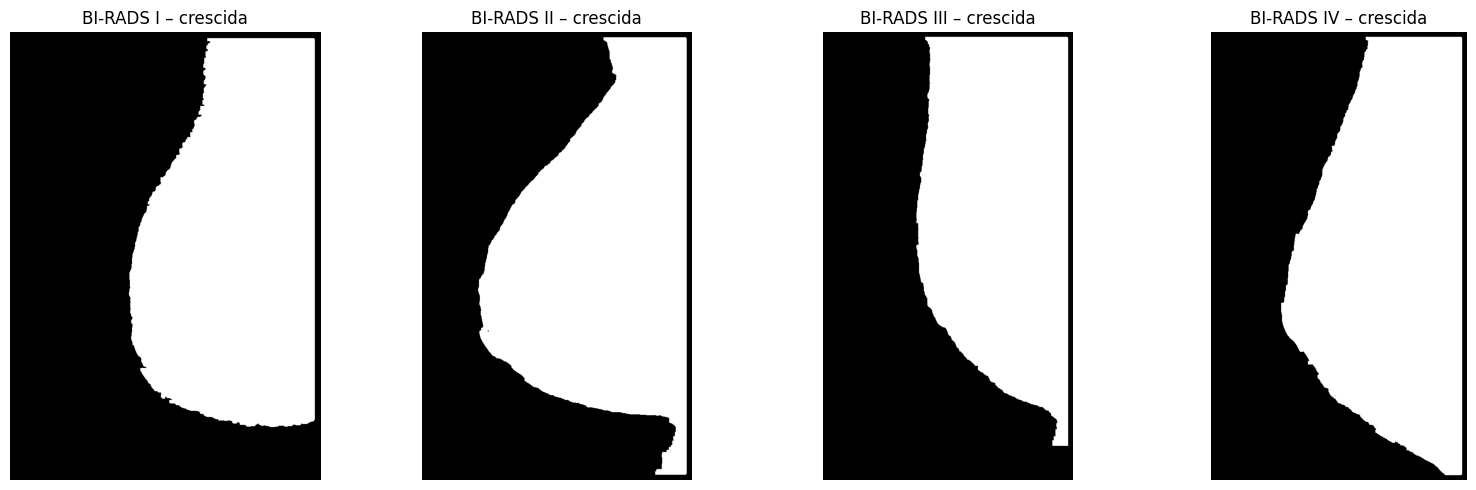

In [8]:
def crescer(nucleo, realcada, limiar_otsu):
    limiar_baixo = max(10, int(limiar_otsu * 0.60))
    candidato = cv2.threshold(realcada, limiar_baixo, 255, cv2.THRESH_BINARY)[1]
    cresc = nucleo.copy()
    for _ in range(15):
        exp = cv2.bitwise_and(cv2.dilate(cresc, np.ones((9, 9), np.uint8)), candidato)
        if np.array_equal(exp, cresc):
            break
        cresc = exp
    cresc = cv2.morphologyEx(cresc, cv2.MORPH_OPEN, np.ones((7, 7), np.uint8))
    n, rot, stats, _ = cv2.connectedComponentsWithStats(cresc)
    if n > 1:
        maior = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        cresc = np.where(rot == maior, 255, 0).astype(np.uint8)
    return cresc

crescidas = {c: crescer(nucleos[c], realcadas[c], limiares[c]) for c in CLASSES}
fig, axs = plt.subplots(1, 4, figsize=(16, 5))
for ax, c in zip(axs, CLASSES):
    ax.imshow(crescidas[c], cmap='gray'); ax.set_title(f'{NOMES[c]} – crescida'); ax.axis('off')
plt.tight_layout(); plt.show()

In [9]:
def finalizar(mascara):
    h, w = mascara.shape
    m = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    m = cv2.dilate(m, np.ones((7, 7), np.uint8), iterations=1)
    bm = max(8, int(min(h, w) * 0.06))
    m[:bm, :] = 0; m[-bm:, :] = 0; m[:, :bm] = 0; m[:, -bm:] = 0
    padded = cv2.copyMakeBorder(m, 1, 1, 1, 1, cv2.BORDER_CONSTANT, value=0)
    cv2.floodFill(padded, None, (0, 0), 128)
    buracos = (padded[1:-1, 1:-1] == 0).astype(np.uint8) * 255
    m = cv2.bitwise_or(m, buracos)
    n, rot, stats, _ = cv2.connectedComponentsWithStats(m)
    if n > 1:
        maior = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        m = np.where(rot == maior, 255, 0).astype(np.uint8)
    return m

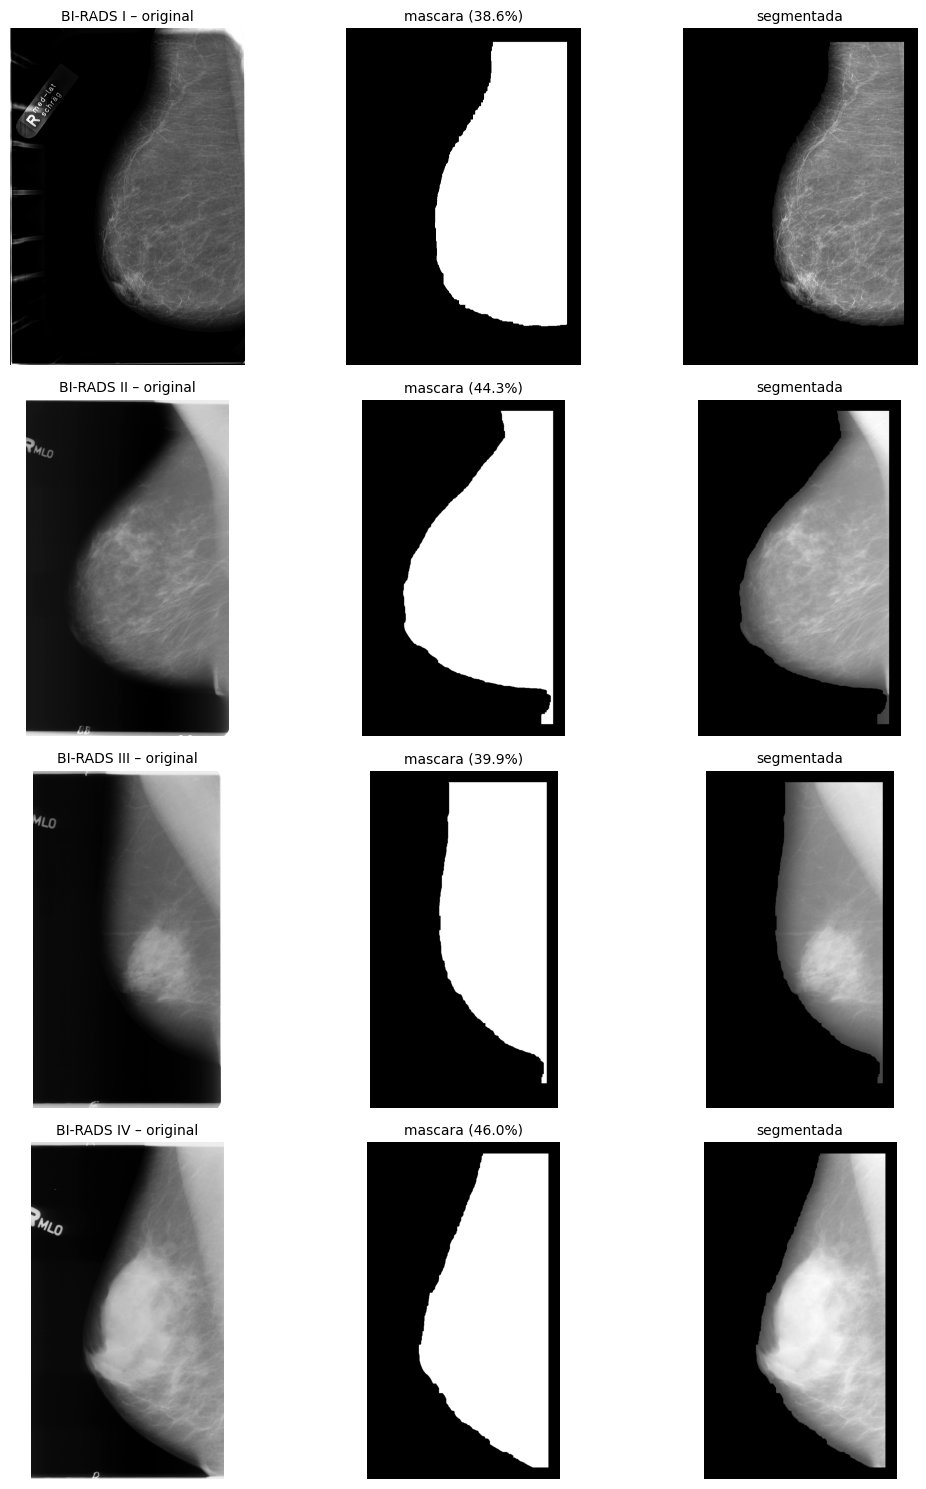

In [10]:
def segmentar(img_original, lado_maximo=1024):
    altura0, largura0 = img_original.shape
    reduzida = preparar(img_original, lado_maximo)
    realcada = realcar(reduzida)
    limiar, binaria = cv2.threshold(realcada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binaria = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    nucleo = maior_componente(binaria)
    if nucleo.max() == 0:
        vazia = np.zeros_like(img_original); return vazia, vazia
    cresc = crescer(nucleo, realcada, limiar)
    m = finalizar(cresc)
    mascara = cv2.resize(m, (largura0, altura0), interpolation=cv2.INTER_NEAREST)
    return mascara, cv2.bitwise_and(img_original, img_original, mask=mascara)

fig, axs = plt.subplots(4, 3, figsize=(11, 15))
for i, c in enumerate(CLASSES):
    masc, seg = segmentar(originais[c])
    cob = 100.0 * (masc > 0).sum() / masc.size
    for ax, im, t in zip(axs[i], [originais[c], masc, seg], [f'{NOMES[c]} – original', f'mascara ({cob:.1f}%)', 'segmentada']):
        ax.imshow(im, cmap='gray'); ax.set_title(t, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()